In [1]:
# ================================================
# PROJECT  : Credit Risk Analysis
# NOTEBOOK : 03 - Feature Analysis
# AUTHOR   : Simran Kumari Singh
# TOOL     : Google Colab
# ================================================

In [3]:
# Import tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from CSV file
df = pd.read_csv('Credit_Risk_Clean.csv')

# Set chart style so all charts look professional
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

# Confirm dataset loaded correctly
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (32581, 19)


In [4]:
# Which Factors Correlate Most With Default? (CORRELATION ANALYSIS)

# Select only number columns — correlation works only with numbers
numeric_cols = [
    'person_age',
    'person_income',
    'person_emp_length',       # how many years employed
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',     # loan amount divided by income
    'cb_person_cred_hist_length',  # credit history length in years
    'loan_status'              # 0 = not defaulted, 1 = defaulted
]
# Calculate correlation of every column with loan_status
corr = df[numeric_cols].corr()['loan_status'].drop('loan_status')
corr = corr.sort_values(ascending=False)

# Print results
print("How strongly each factor is related too loan Default:")
print("=" * 55)
print("(positive = increase default risk)")
print("(negative = decrease default risk)")
print("=" * 55)

# Loop through each factor and print its correlation value
for col, val in corr.items():
  #Decide direction based on positive or negative value
  if val > 0:
    direction = "↑ increases default risk"
  else:
    direction = "↓ decreases default risk"

  #Print each factor name, value, and direction
  print(f"{col:35s}: {val:+.4f} {direction}")


How strongly each factor is related too loan Default:
(positive = increase default risk)
(negative = decrease default risk)
loan_percent_income                : +0.3794 ↑ increases default risk
loan_int_rate                      : +0.3194 ↑ increases default risk
loan_amnt                          : +0.1054 ↑ increases default risk
cb_person_cred_hist_length         : -0.0155 ↓ decreases default risk
person_age                         : -0.0216 ↓ decreases default risk
person_emp_length                  : -0.0822 ↓ decreases default risk
person_income                      : -0.1444 ↓ decreases default risk


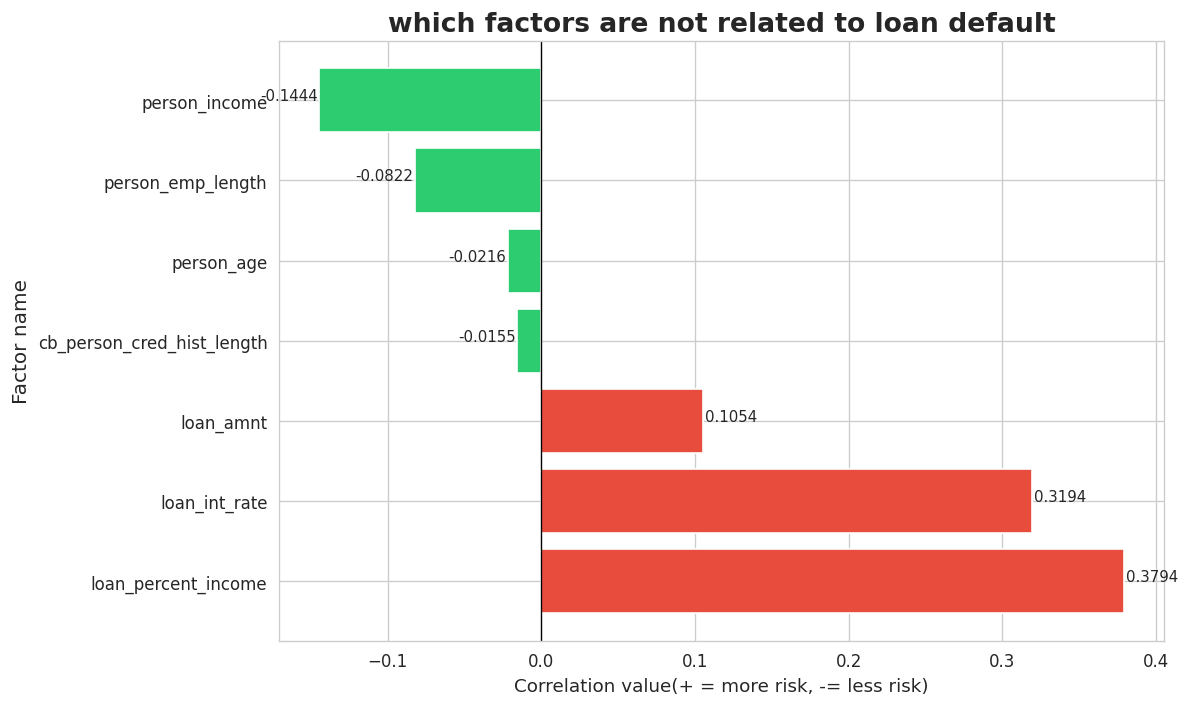

In [6]:
# Chart 1 : Bar Chart of Correlations
# visual version of correlation analysis

# 1. Create color list — red if positive, green if negative
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr.values]

# 2. Set chart size - (width, height) in inches
plt.figure(figsize=(10, 6))

# 3. Draw horizontal bar chart
bars = plt.barh(corr.index, corr.values, color=colors)

#4. Add a vertical black lines at zero for reference
plt.axvline(x=0, color='black', linewidth=0.8)

# 5. Add chart title and axis labels
plt.title('which factors are not related to loan default',
          fontsize=16, fontweight='bold')
plt.xlabel('Correlation value(+ = more risk, -= less risk)', fontsize=11)
plt.ylabel('Factor name', fontsize=12)

# 6. Add the exact number on each bar
for bar, val in zip(bars, corr.values):
  #if positive value, put text to the right of bar
  # if negative value, put text to the left of bar
  plt.text(
      val + 0.001 if val >= 0 else val - 0.001,
      bar.get_y() + bar.get_height() / 2,
      f'{val:.4f}',
      ha='left' if val >= 0 else 'right',
      fontsize=9
  )

plt.tight_layout()
plt.show()

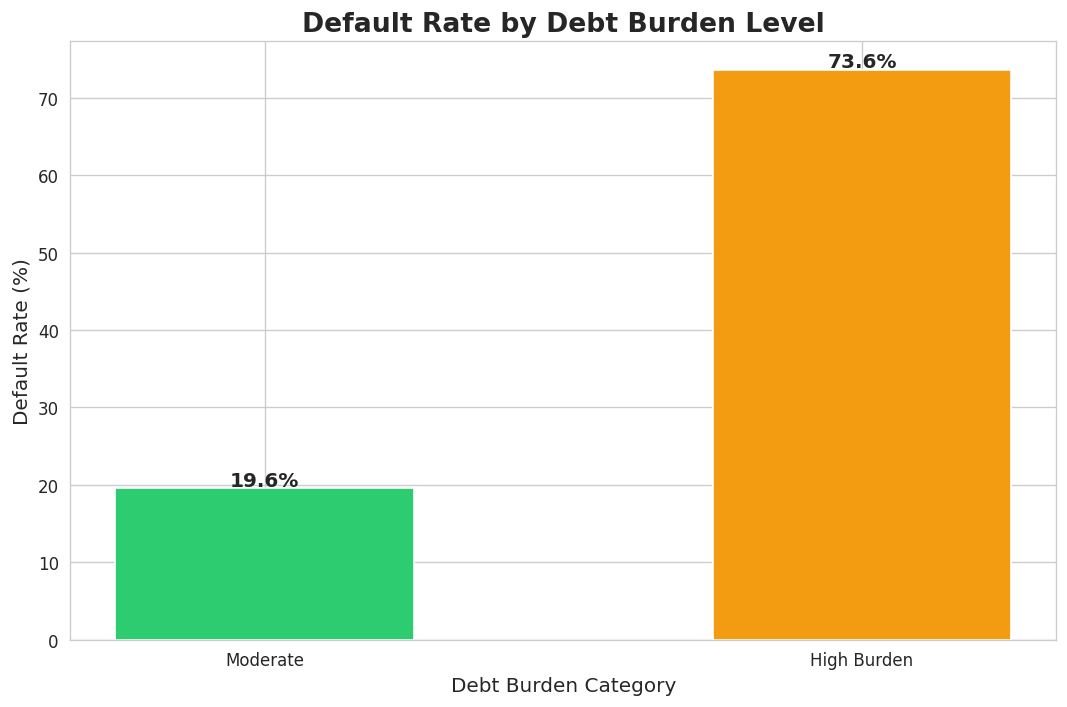

In [7]:
# Chart 2: Does high debt burden lead to more defaults? (Debt Burden vs Default Rate)

# debt_burden column has 3 values we created in Excel:
#   Manageable  = loan is less than 20% of income
#   Moderate    = loan is 20% to 40% of income
#   High Burden = loan is more than 40% of income

# 1. Group data by debt_burden category
debt_default = df.groupby('debt_burden')['loan_status'].mean() * 100
debt_default = debt_default.reset_index()  # convert to normal table format
debt_default.columns = ['debt_burden', 'default_rate']  # rename columns

# 2. Sort in logical order from least to most burden
order = ['Manageable', 'Moderate', 'High Burden']
debt_default['debt_burden'] = pd.Categorical(
    debt_default['debt_burden'],
    categories=order,
    ordered=True
)
debt_default = debt_default.sort_values('debt_burden')

# 3. Draw the bar chart
plt.figure(figsize=(9, 6))
bars = plt.bar(
    debt_default['debt_burden'],   # x axis = debt burden categories
    debt_default['default_rate'],  # y axis = default rate percentage
    color=['#2ecc71', '#f39c12', '#e74c3c'],  # green, orange, red
    width=0.5   # width of each bar
)

# 4. Chart title and labels
plt.title('Default Rate by Debt Burden Level',
          fontsize=16, fontweight='bold')
plt.xlabel('Debt Burden Category', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# 5. Add percentage label on top of each bar
for bar, val in zip(bars, debt_default['default_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # center of bar (x position)
        bar.get_height() + 0.3,              # just above bar (y position)
        f'{val:.1f}%',                        # text to show
        ha='center',                          # center align text
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


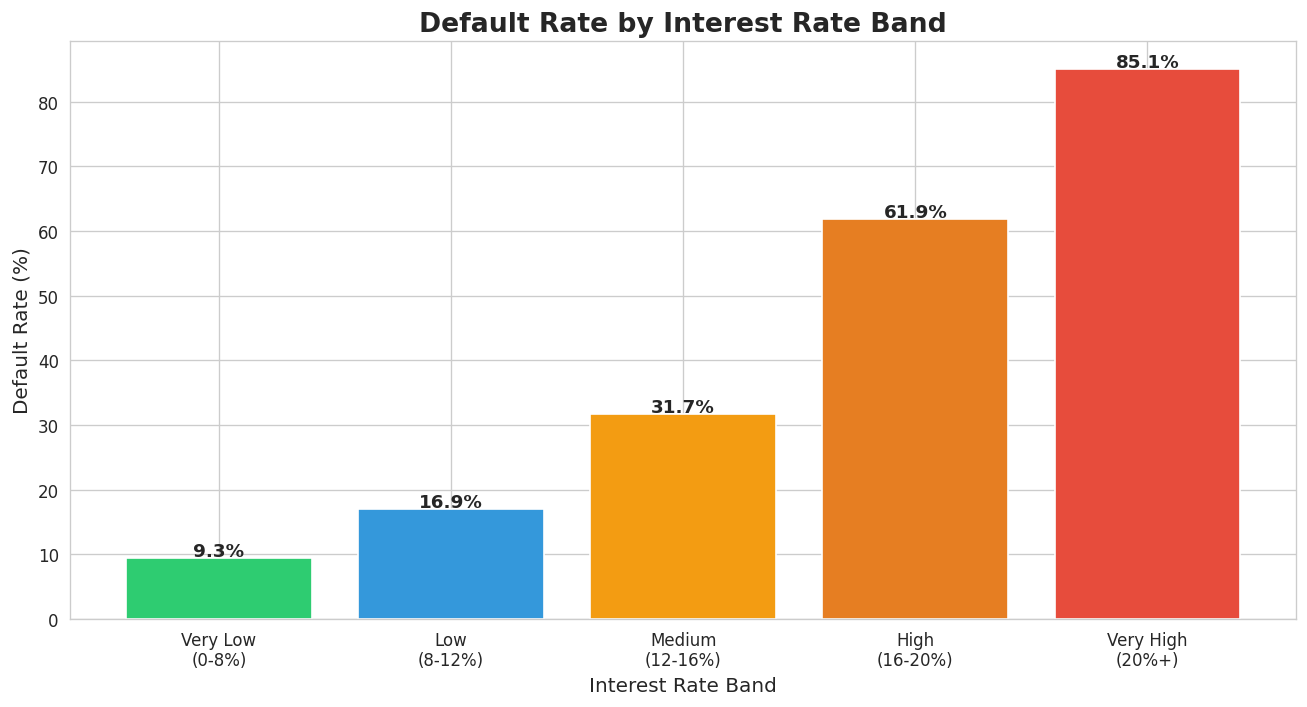

In [8]:
# Chart 3: Do higher interest rate loans default more?(Interest Rate Band vs Default Rate)
# Higher interest rate = bank already thinks customer is risky

# 1. Split loan_int_rate into 5 groups using pd.cut()
df['int_rate_band'] = pd.cut(
    df['loan_int_rate'],
    bins=[0, 8, 12, 16, 20, 30],
    labels=[
        'Very Low\n(0-8%)',
        'Low\n(8-12%)',
        'Medium\n(12-16%)',
        'High\n(16-20%)',
        'Very High\n(20%+)'
    ]
)
# 2. Calculate default rate for each interest rate group
rate_default = df.groupby('int_rate_band', observed=True)['loan_status'].mean() * 100
rate_default = rate_default.reset_index()
rate_default.columns = ['int_rate_band', 'default_rate']

# 3. Draw bar chart
plt.figure(figsize=(11, 6))
bars = plt.bar(
    rate_default['int_rate_band'].astype(str),  # convert to string for x axis
    rate_default['default_rate'],
    color=['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
    # colors go from green (safe) to red (risky)
)

plt.title('Default Rate by Interest Rate Band',
          fontsize=16, fontweight='bold')
plt.xlabel('Interest Rate Band', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# 4. Add percentage on top of each bar
for bar, val in zip(bars, rate_default['default_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()



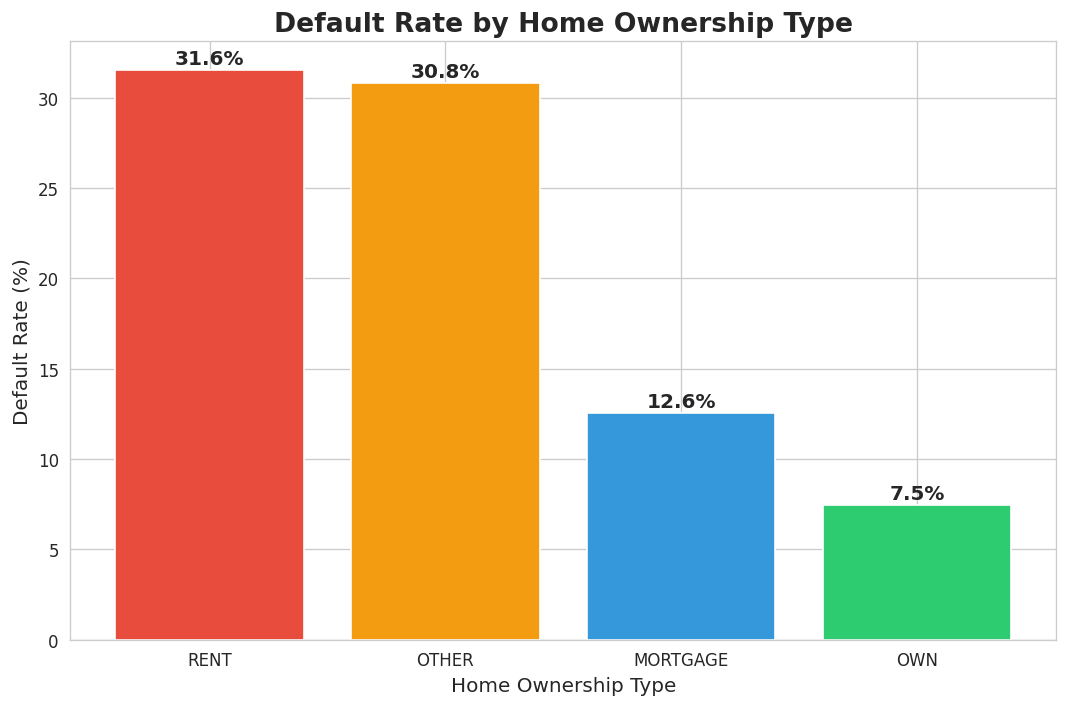

In [9]:
 # Chart 4: Do renters default more than homeowners? (Home Ownership vs Default Rate)

 # 1. Group by home ownership type and calculate default rate
home_default = df.groupby('person_home_ownership')['loan_status'].mean() * 100
home_default = home_default.reset_index()
home_default.columns = ['ownership', 'default_rate']

# 2. Sort from highest to lowest default rate
home_default = home_default.sort_values('default_rate', ascending=False)

# 3. Draw bar chart
plt.figure(figsize=(9, 6))
bars = plt.bar(
    home_default['ownership'],
    home_default['default_rate'],
    color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
)

plt.title('Default Rate by Home Ownership Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Home Ownership Type', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

# 4. Add percentage labels on each bar
for bar, val in zip(bars, home_default['default_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()


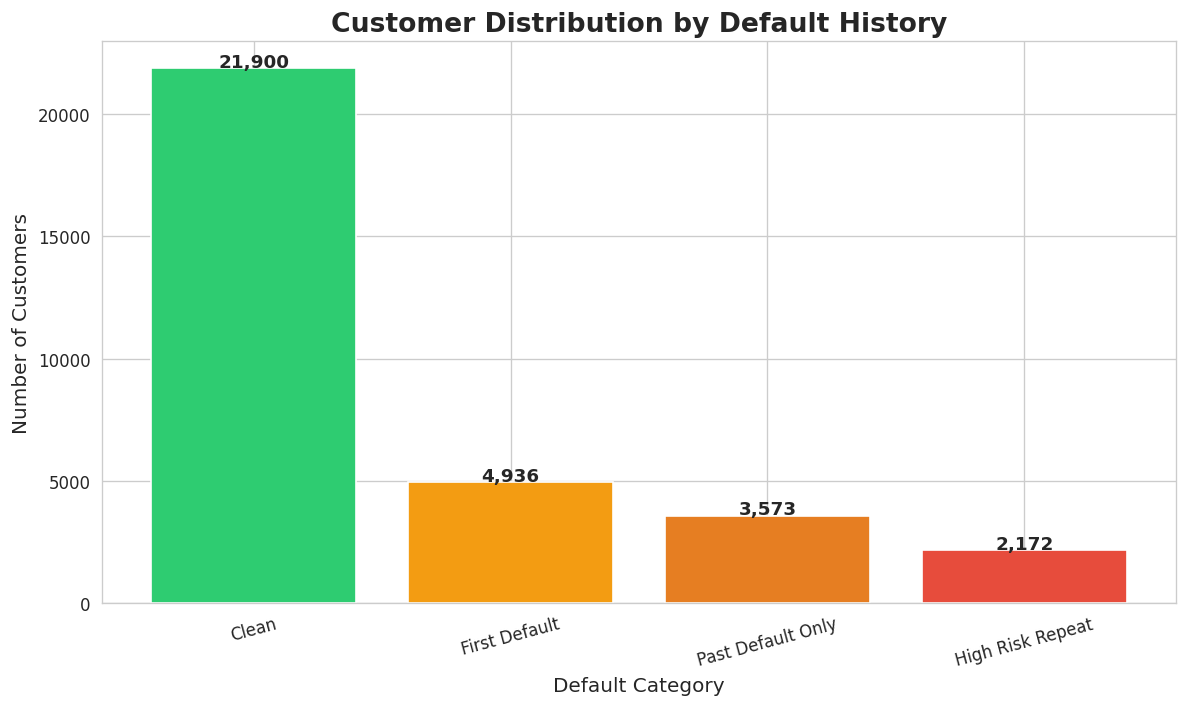

In [10]:
# Chart 5: How many customers are repeat defaulters? (Repeat Defaulter Breakdown)

# 1. Count how many customers fall in each repeat defaulter category
repeat_counts = df['repeat_defaulter'].value_counts().reset_index()
repeat_counts.columns = ['category', 'count']

#2. Draw bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(
    repeat_counts['category'],
    repeat_counts['count'],
    color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
)

plt.title('Customer Distribution by Default History',
          fontsize=16, fontweight='bold')
plt.xlabel('Default Category', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=15)  # rotate x labels slightly so they dont overlap

# 3. Add count number on top of each bar
for bar, val in zip(bars, repeat_counts['count']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:,}',   # :, adds comma separator for thousands
        ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()


In [12]:
# KEY FINDINGS SUMMARY

print("=" * 55)
print("    KEY FINDINGS — FEATURE ANALYSIS COMPLETE")
print("=" * 55)

# 1. Calculate overall default rate
total_customers = len(df)               # total number of rows
total_defaulters = df['loan_status'].sum()  # sum of 1s = count of defaulters
overall_default_rate = total_defaulters / total_customers * 100

print(f"\n Total Customers          : {total_customers:,}")
print(f" Total Defaulters         : {total_defaulters:,}")
print(f" Overall Default Rate     : {overall_default_rate:.2f}%")

# 2. Find which factor has strongest correlation with default
strongest_factor = corr.abs().idxmax()  # .abs() = ignore +/- sign
print(f"\n Strongest Default Factor : {strongest_factor}")

# 3. Calculate default rate for high burden customers specifically
high_burden_mask = df['debt_burden'] == 'High Burden'  # filter condition
high_burden_rate = df[high_burden_mask]['loan_status'].mean() * 100
print(f" High Burden Default Rate : {high_burden_rate:.2f}%")

# 4. Count repeat defaulters (most dangerous segment)
repeat_mask = df['repeat_defaulter'] == 'High Risk Repeat'
repeat_count = repeat_mask.sum()  # count of True values
print(f" High Risk Repeat Count   : {repeat_count:,}")

# 5. Default rate for very high interest rate loans (above 20%)
high_rate_mask = df['loan_int_rate'] > 20
high_rate_default = df[high_rate_mask]['loan_status'].mean() * 100
print(f" Default Rate (Rate>20%)  : {high_rate_default:.2f}%")

print("\n" + "=" * 55)
print(" Notebook 3 Complete! Take screenshots now.")
print("=" * 55)

    KEY FINDINGS — FEATURE ANALYSIS COMPLETE

 Total Customers          : 32,581
 Total Defaulters         : 7,108
 Overall Default Rate     : 21.82%

 Strongest Default Factor : loan_percent_income
 High Burden Default Rate : 73.63%
 High Risk Repeat Count   : 2,172
 Default Rate (Rate>20%)  : 85.14%

 Notebook 3 Complete! Take screenshots now.
